# Modulo 2 Sesion 12 — Deteccion de oitliers
### Diplomado: Machine Learning en Seguros · FC UNAM
### Viernes 15 de mayo de 2026  ·  18:00 - 21:00 h (3 horas)

---
## Setup


In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings
warnings.filterwarnings('ignore')

mpl.rcParams['figure.dpi'] = 110
mpl.rcParams['axes.spines.top']  = False
mpl.rcParams['axes.spines.right'] = False

df = pd.read_parquet('../Modulo_1/sesion_10/datos/cartera_q1_2026_final.parquet')
print(f'Tabla maestra: {df.shape}')

COLORES = {
    'GMM':'#0D7A8A','Autos':'#1A5276',
    'Vida':'#1E8449','Accidentes Personales':'#6C3483',
    'BAJO':'#1E8449','MEDIO':'#F4A261','ALTO':'#C0392B',
}

Tabla maestra: (50000, 52)


Generamos la funcion para identificar outliers

In [2]:
def detectar_outliers_iqr(datos, multiplicador=1.5):
    """
    Detecta outliers usando método IQR
    """
    Q1 = np.percentile(datos, 25)
    Q3 = np.percentile(datos, 75)
    IQR = Q3 - Q1
    
    limite_inferior = Q1 - multiplicador * IQR
    limite_superior = Q3 + multiplicador * IQR
    
    outliers_mask = (datos < limite_inferior) | (datos > limite_superior)
    
    return {
        'n_siniestros': len(datos),
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'limite_inferior': limite_inferior,
        'limite_superior': limite_superior,
        'outliers': len(datos[outliers_mask]),
        'indices': np.where(outliers_mask)[0]
    }

Tomamos los datos de cada ramo para identificar outliers

In [3]:
ramos = ["GMM", "Vida", "Autos", "Accidentes Personales"]
resultados = []

for ramo in ramos:
    datos = df[(df["ramo"] == ramo) & (df["monto_pagado"] > 0)]["monto_pagado"]
    out = detectar_outliers_iqr(datos)
    resultados.append(out)

for i in range(0,3):
    print(f"Ramo: {ramos[i]}")
    print(f"Número de siniestros con monto mayor a 0: {resultados[i]['n_siniestros']}")
    print(f"Q1: {resultados[i]['Q1']:.2f}")
    print(f"Q3: {resultados[i]['Q3']:.2f}")
    print(f"IQR: {resultados[i]['IQR']:.2f}")
    print(f"Límite Superior: {resultados[i]['limite_superior']:.2f}")
    print(f"Outliers detectados: {resultados[i]['outliers']}")
    print()



Ramo: GMM
Número de siniestros con monto mayor a 0: 2813
Q1: 8135.10
Q3: 41644.06
IQR: 33508.96
Límite Superior: 91907.50
Outliers detectados: 218

Ramo: Vida
Número de siniestros con monto mayor a 0: 905
Q1: 8034.00
Q3: 43137.71
IQR: 35103.71
Límite Superior: 95793.27
Outliers detectados: 61

Ramo: Autos
Número de siniestros con monto mayor a 0: 1846
Q1: 8787.82
Q3: 42231.96
IQR: 33444.14
Límite Superior: 92398.17
Outliers detectados: 141



In [4]:
resumen_out = pd.DataFrame(resultados)
resumen_out

,n_siniestros,Q1,Q3,IQR,limite_inferior,limite_superior,outliers,indices
0,2813,8135.1000,41644.06,33508.9600,-42128.34000,91907.50000,218,"[7, 12, 23, 27, 32, 33, 44, 55, 58, 110, 123, ..."
1,905,8034.0000,43137.71,35103.7100,-44621.56500,95793.27500,61,"[14, 60, 95, 119, 135, 143, 164, 188, 209, 211..."
2,1846,8787.8225,42231.96,33444.1375,-41378.38375,92398.16625,141,"[6, 16, 17, 32, 41, 54, 66, 67, 71, 132, 133, ..."
3,623,8157.4900,39459.93,31302.4400,-38796.17000,86413.59000,44,"[1, 15, 17, 26, 47, 53, 79, 81, 91, 95, 115, 1..."


In [5]:
df.columns

Index(['id_poliza', 'num_poliza', 'nombre', 'apellido_paterno',
       'apellido_materno', 'rfc', 'edad', 'sexo', 'estado_civil', 'ocupacion',
       'ramo', 'plan', 'fecha_emision', 'fecha_inicio_vigencia',
       'fecha_fin_vigencia', 'num_renovaciones', 'status_poliza',
       'motivo_baja', 'canal_venta', 'marca_vehiculo', 'modelo_vehiculo',
       'tipo_vehiculo', 'suma_asegurada', 'deducible', 'prima_neta',
       'prima_total', 'forma_pago', 'agente_id', 'estado', 'municipio',
       'codigo_postal', 'nombre_agente', 'region', 'tipo_agente',
       'comision_pct', 'n_siniestros', 'monto_reclamado', 'monto_pagado',
       'tiene_abierto', 'tipo_principal', 'prima_mensual', 'loss_ratio',
       'comision_est', 'nivel_riesgo', 'anio_emision', 'mes_emision',
       'trimestre', 'segmento_prima_fijo', 'cuartil_prima', 'cod_ramo',
       'anio_poliza', 'ramo_desde_codigo'],
      dtype='object')

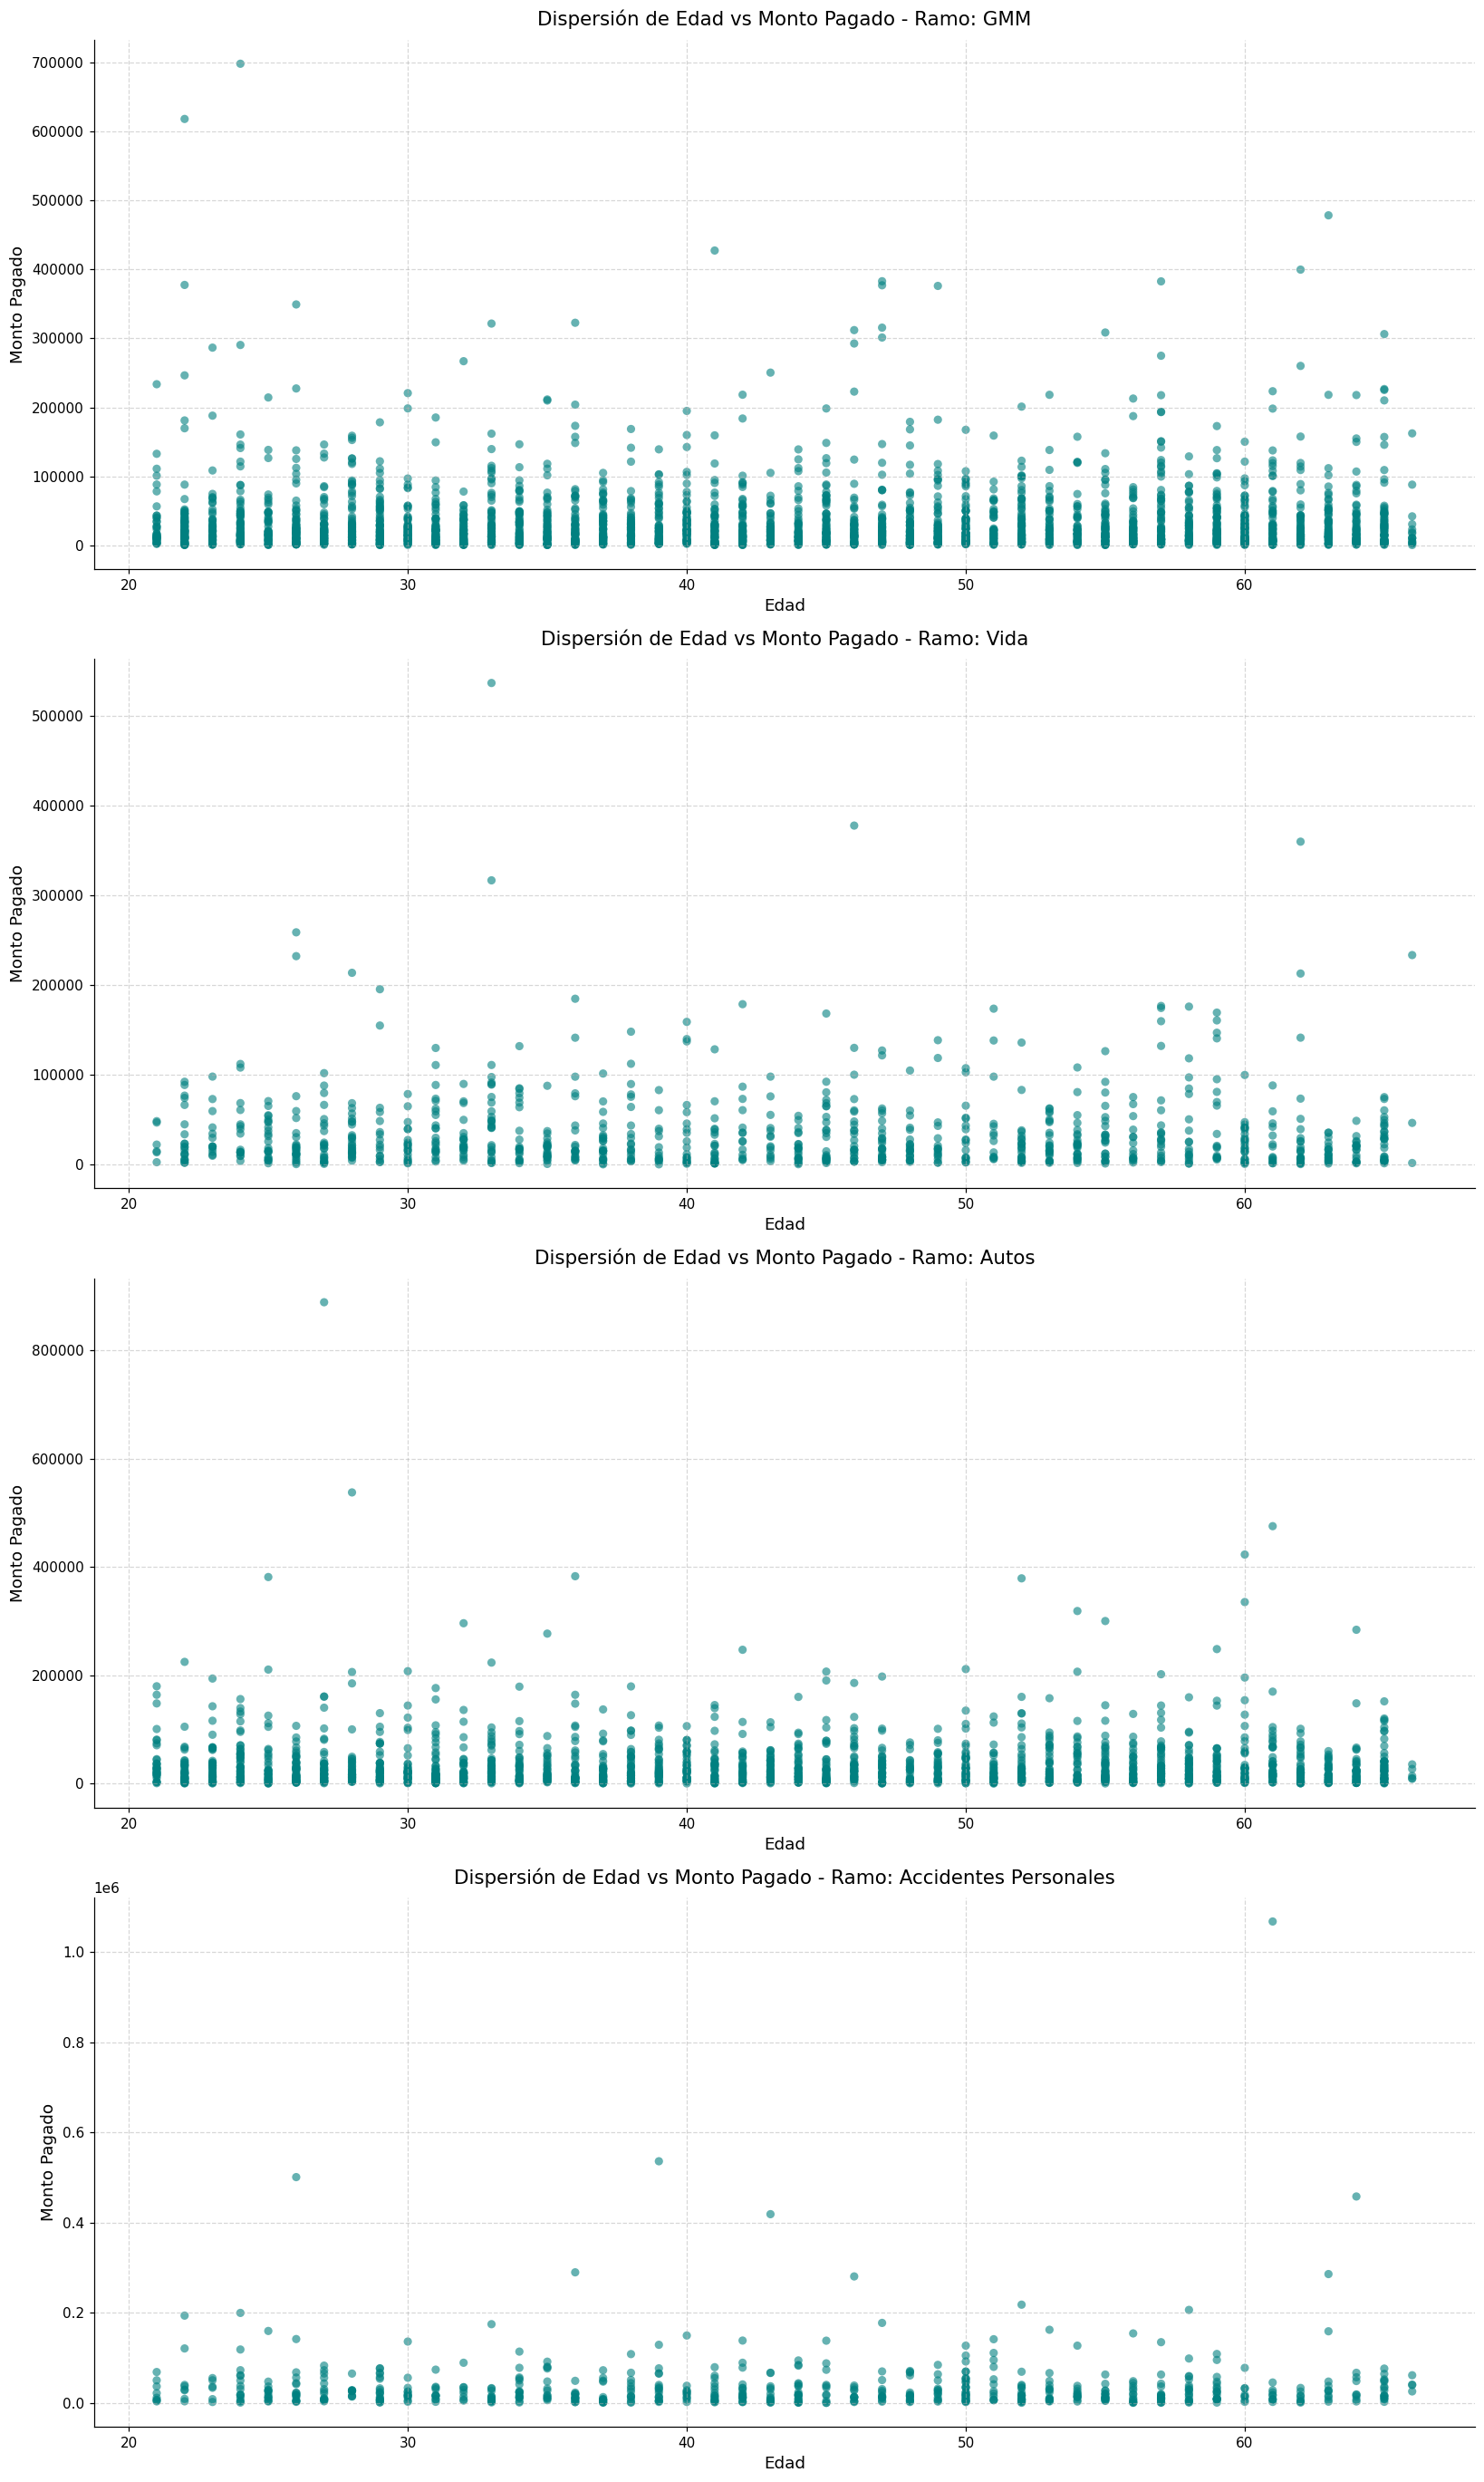

In [6]:

fig, ax = plt.subplots(4, 1, figsize=(15, 25), sharex=False)

for i, ramo in enumerate(ramos):
    # Filtrar datos de manera eficiente para el ramo actual
    df_filtrado = df[(df["ramo"] == ramo) & (df["monto_pagado"] > 0)]
    
    x = df_filtrado["edad"]
    y = df_filtrado["monto_pagado"]
    
    # Dibujar el gráfico de dispersión en el eje correspondiente
    ax[i].scatter(x, y, alpha=0.6, color="teal", edgecolor="none")
    
    # Personalización de cada subgráfico
    ax[i].set_title(f"Dispersión de Edad vs Monto Pagado - Ramo: {ramo}", fontsize=14, pad=10)
    ax[i].set_xlabel("Edad", fontsize=12)
    ax[i].set_ylabel("Monto Pagado", fontsize=12)
    ax[i].grid(True, linestyle="--", alpha=0.5)  # Cuadrícula para mejorar lectura

# 3. Ajustar diseño para evitar que se encimen los textos y mostrar
plt.tight_layout()
plt.show()

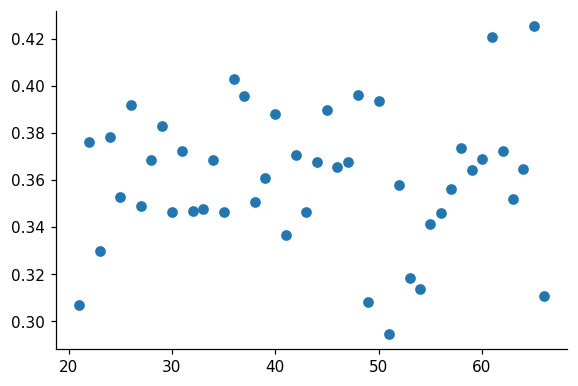

In [26]:
df_gmm = df[df["ramo"] == "GMM"]

df_gmm_anio = df_gmm.groupby("edad").agg(
                    total_siniestros = ("n_siniestros", "sum"),
                    total_emisiones = ("id_poliza", "count")
).assign(frecuencia = lambda x: x["total_siniestros"]/x["total_emisiones"]).reset_index()

df_gmm_anio
plt.figure(figsize=(6,4))
plt.scatter(x=df_gmm_anio["edad"], y=(df_gmm_anio["frecuencia"]))
plt.show()

In [23]:
df_gmm_anio.describe()

,edad,total_siniestros,total_emisiones,frecuencia
count,46.000000,46.000000,46.000000,46.000000
mean,43.500000,177.086957,489.804348,0.360459
std,13.422618,26.871568,58.787988,0.028893
min,21.000000,50.000000,161.000000,0.294606
25%,32.250000,170.000000,486.000000,0.346233
50%,43.500000,182.500000,502.500000,0.364346
75%,54.750000,192.750000,515.250000,0.375537
max,66.000000,208.000000,542.000000,0.425358
